# HOG-Based Person Retrieval

In this exercise, you will build a **simple person-search system** using the **Histogram of Oriented Gradients (HOG) descriptor and a sliding‐window detector**. You will be given a template image containing a person, and a folder of larger scene images. Your goal is to:



1.   Using a HOG descriptor and a sliding window, **scan each image and compute the distance between the window’s HOG descriptor and the template’s descriptor**. Select the location with the minimum distance as the best match.
2.   **Rank images by similarity**
3.   **Visualize the detection results, including HOG descriptors of the template and the best windows**

Results should look similar to the following:

<img src="P4_E2.png"/>


RECOMMENDATIONS:
- Do it step by step, first top-1 and then extend it for top-3.
- Do not leave the exercise blank, do as much as you know and present it properly.
- Use whatever distance suits you better but **specify it**.




In [27]:
import os
import glob
from skimage.feature import hog
from matplotlib import patches
import numpy as np
from skimage import io, color, transform, feature, measure, exposure
import matplotlib.pyplot as plt

# Common HOG parameters (same style as earlier in the notebook)
hog_params = dict(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(3, 3),
    block_norm='L2-Hys',
    feature_vector=True
)



In [28]:

import os, glob
from matplotlib import patches

def detect_person_hog(image, template, hog_params, step=8):
    tpl_h, tpl_w = template.shape
    # template feature
    tpl_feat = hog(template, visualize=False, **hog_params)
    h, w = image.shape
    best = {'dist': np.inf, 'x': 0, 'y': 0}
    for y in range(0, h - tpl_h + 1, step):
        for x in range(0, w - tpl_w + 1, step):
            window = image[y:y+tpl_h, x:x+tpl_w]
            # compute HOG for window
            win_feat = hog(window, visualize=False, **hog_params)
            d = np.linalg.norm(win_feat - tpl_feat)
            if d < best['dist']:
                best.update({'dist': d, 'x': x, 'y': y})
    return best


In [29]:
def ensure_gray(image):
    if image.ndim == 3:
        if image.shape[-1] == 4:
            image = color.rgba2rgb(image)
        if image.shape[-1] == 3:
            return color.rgb2gray(image)
    return image

def normalize(image):
    if image.max() > 1.:
        image = image.astype(np.float32) / 255.
    return image

In [58]:
# Continue Here...

def find_topN_HOG(reference_path, folder='images', topN = 3):
    img = io.imread(reference_path)
    tpl = normalize(ensure_gray(img))
    tpl_h, tpl_w = tpl.shape

    # run detection on all images in folder
    img_paths = sorted(glob.glob(os.path.join(folder,"*")))
    all_candidates = []
    for p in img_paths:
        img = ensure_gray(io.imread(p))
        img = normalize(img)

        # find best match
        best = detect_person_hog(img, tpl, hog_params, step=8)

        # compute HOG visualization for full image
        _, hog_img_full = hog(img, visualize=True, **hog_params)
        hog_img_full = exposure.rescale_intensity(hog_img_full, in_range=(0, hog_img_full.max()))
        hog_img_full = hog_img_full[best['y']:best['y']+tpl_h, best['x']:best['x']+tpl_w]
        all_candidates.append((best, img, hog_img_full, p))
        
    sorted_candidates = sorted(all_candidates, key=lambda x: x[0]['dist'], reverse=False)
    topN_candidates = sorted_candidates[:topN]
    
    fig, ax = plt.subplots(2, len(topN_candidates)+1, figsize=(15, 6))

    ax[0,0].imshow(topN_candidates[0][1], cmap='gray')
    ax[0,0].set_title("Template")
    ax[0,0].axis('off')
    
    ax[1,0].imshow(topN_candidates[0][2], cmap='gray')
    ax[1,0].set_title("Template HOG")
    ax[1,0].axis('off')
    for i in range(1,len(topN_candidates)+1):
        
        ax[0,i].imshow(topN_candidates[i-1][1], cmap='gray')
        rect = patches.Rectangle((topN_candidates[i-1][0]['x'], topN_candidates[i-1][0]['y']), tpl_w, tpl_h,
                                 linewidth=2, edgecolor='g', facecolor='none')
        ax[0,i].add_patch(rect)
        ax[0,i].set_title(f"Rank {i}\n {os.path.basename(topN_candidates[i-1][3])}\n HOG dist= {topN_candidates[i-1][0]['dist']:.2f}")
        ax[0,i].axis('off')

        ax[1,i].imshow(topN_candidates[i-1][2], cmap='gray')
        ax[1,i].set_title(f"Rank {i} HOG window")
        ax[1,i].axis('off')


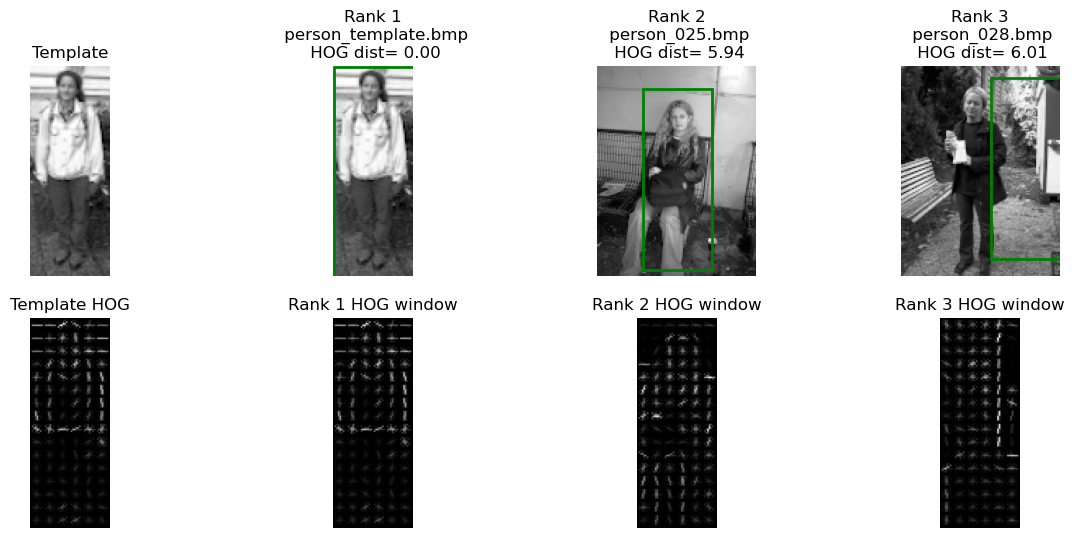

In [59]:
find_topN_HOG(reference_path='images/person_template.bmp',folder='images', topN=3)